# CIHI Hospitalization Data — GBD + AFU Canada Paper
**Source:** Hospital Morbidity Database (HMDB) / OMHRS, 2024–2025  
**Release:** February 19, 2026 | Canadian Institute for Health Information

This notebook extracts and visualizes CIHI hospitalization data to complement
the GBD 2023 disease burden analysis. Key contributions:
1. Top hospitalization diagnoses for **age 65+** (Table 3) — validates GBD findings
2. Top diagnoses by **province** (Table 2) — Ontario, BC, Alberta, Manitoba
3. National **hospitalization rate trend** 2020–2025 (Table 1)
4. **GBD–CIHI alignment analysis** — do top DALY causes match top hospital causes?

**Authors:** Narayanee (Amala K J), Dr. Parthiban Natarajan, Dr. Shanthi Johnson  
**Institution:** University of Windsor


## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'Canada':           '#2563EB',
    'Ontario':          '#16A34A',
    'British Columbia': '#9333EA',
    'Alberta':          '#DC2626',
    'Manitoba':         '#D97706',
    'cardiovascular':   '#EF4444',
    'respiratory':      '#3B82F6',
    'neurological':     '#8B5CF6',
    'musculoskeletal':  '#F59E0B',
    'other':            '#6B7280',
}

# FILE PATH — update if needed
CIHI_FILE = "C:\\Users\\amala\\Downloads\\dad-hmdb-childbirth-2024-2025-data-tables-en.xlsx"

print('Libraries loaded.')

Libraries loaded.


## 2. Load All CIHI Tables

In [4]:
xl = pd.read_excel(CIHI_FILE, sheet_name=None)
print('Sheets loaded:', list(xl.keys()))

Sheets loaded: ['Instructions', 'Table of contents', 'Table 1', 'Table 2', 'Table 3', 'Table 4', 'Table 5 ', 'Table 6', 'Table 7', 'Table 8', 'Contact information']


## 3. Table 1 — National Hospitalization Rate Trend (2020–2025)

In [5]:
def parse_table1(xl):
    t1 = xl['Table 1']
    # Data starts at row index 2 (0-indexed)
    rows = []
    for i in range(2, 7):
        row = t1.iloc[i]
        vals = [v for v in row.values if pd.notna(v)]
        if len(vals) >= 3:
            rows.append({
                'fiscal_year': str(vals[0]),
                'hosp_rate_per100k': float(vals[1]),
                'avg_los_days': float(vals[2])
            })
    return pd.DataFrame(rows)

trend_df = parse_table1(xl)
print('National Hospitalization Rate Trend:')
print(trend_df.to_string(index=False))

National Hospitalization Rate Trend:
fiscal_year  hosp_rate_per100k  avg_los_days
  2020–2021        7227.723290      5.856509
  2021–2022        7536.582766      6.017255
  2022–2023        7565.786002      6.138420
  2023–2024        7565.308741      6.124284
  2024–2025        7560.295287      6.148335


## 4. Table 3 — Top 10 Hospitalizations for Age 65+ (2024–2025)

In [6]:
def parse_table3_age65plus(xl):
    """
    Extracts the 65+ age group section from Table 3.
    Returns clean DataFrame with rank, diagnosis, count, pct, avg_los.
    """
    t3 = xl['Table 3']
    # Row 31 onwards is the 65+ group (0-indexed)
    rows = []
    for i in range(31, 41):
        row = t3.iloc[i]
        vals = [v for v in row.values if pd.notna(v)]
        if len(vals) >= 5:
            rows.append({
                'rank':       int(float(vals[0])) if i == 31 else int(float(vals[0])),
                'diagnosis':  str(vals[1]),
                'n_hosp':     int(float(vals[2])),
                'pct':        float(vals[3]),
                'avg_los':    float(vals[4])
            })
        elif len(vals) == 4:  # no age group repeated
            rows.append({
                'rank':       int(float(vals[0])),
                'diagnosis':  str(vals[1]),
                'n_hosp':     int(float(vals[2])),
                'pct':        float(vals[3]),
                'avg_los':    None
            })
    return pd.DataFrame(rows)

# Manual extraction (most robust for messy CIHI format)
hosp_65plus = pd.DataFrame([
    {'rank': 1,  'diagnosis': 'COPD and bronchitis',                          'n_hosp': 68321, 'pct': 4.633, 'avg_los': 7.31,  'gbd_category': 'Respiratory'},
    {'rank': 2,  'diagnosis': 'Heart failure',                                'n_hosp': 61591, 'pct': 4.176, 'avg_los': 9.71,  'gbd_category': 'Cardiovascular'},
    {'rank': 3,  'diagnosis': 'Neurocognitive disorders',                     'n_hosp': 49996, 'pct': 3.390, 'avg_los': 17.14, 'gbd_category': 'Neurological'},
    {'rank': 4,  'diagnosis': 'Pneumonia',                                    'n_hosp': 49060, 'pct': 3.327, 'avg_los': 7.92,  'gbd_category': 'Respiratory'},
    {'rank': 5,  'diagnosis': 'Osteoarthritis of the knee',                   'n_hosp': 45585, 'pct': 3.091, 'avg_los': 2.10,  'gbd_category': 'Musculoskeletal'},
    {'rank': 6,  'diagnosis': 'Other medical care (palliative/chemotherapy)', 'n_hosp': 40829, 'pct': 2.769, 'avg_los': 9.08,  'gbd_category': 'Other'},
    {'rank': 7,  'diagnosis': 'Acute myocardial infarction',                  'n_hosp': 40284, 'pct': 2.732, 'avg_los': 5.61,  'gbd_category': 'Cardiovascular'},
    {'rank': 8,  'diagnosis': 'Fracture of femur',                            'n_hosp': 39700, 'pct': 2.692, 'avg_los': 11.41, 'gbd_category': 'Musculoskeletal'},
    {'rank': 9,  'diagnosis': 'Cerebral infarction',                          'n_hosp': 32662, 'pct': 2.215, 'avg_los': 10.43, 'gbd_category': 'Neurological'},
    {'rank': 10, 'diagnosis': 'Other urinary system diseases (UTI)',           'n_hosp': 26443, 'pct': 1.793, 'avg_los': 7.82,  'gbd_category': 'Other'},
])

print('Top 10 Inpatient Hospitalizations — Age 65+, Canada, 2024–2025')
print('=' * 75)
print(hosp_65plus[['rank','diagnosis','n_hosp','pct','avg_los','gbd_category']]
      .to_string(index=False))
print(f"\nTotal hospitalizations in 65+ top 10: {hosp_65plus['n_hosp'].sum():,}")

Top 10 Inpatient Hospitalizations — Age 65+, Canada, 2024–2025
 rank                                    diagnosis  n_hosp   pct  avg_los    gbd_category
    1                          COPD and bronchitis   68321 4.633     7.31     Respiratory
    2                                Heart failure   61591 4.176     9.71  Cardiovascular
    3                     Neurocognitive disorders   49996 3.390    17.14    Neurological
    4                                    Pneumonia   49060 3.327     7.92     Respiratory
    5                   Osteoarthritis of the knee   45585 3.091     2.10 Musculoskeletal
    6 Other medical care (palliative/chemotherapy)   40829 2.769     9.08           Other
    7                  Acute myocardial infarction   40284 2.732     5.61  Cardiovascular
    8                            Fracture of femur   39700 2.692    11.41 Musculoskeletal
    9                          Cerebral infarction   32662 2.215    10.43    Neurological
   10          Other urinary system d

## 5. Table 2 — Top Diagnoses by Province (our 4 AFU provinces)

In [7]:
# Extracted from Table 2 — top conditions for Ontario, BC, Alberta, Manitoba
# Filtered to GBD-relevant elderly diseases (cardiovascular, respiratory, neurological, musculoskeletal)

prov_data = pd.DataFrame([
    # Ontario (Ont.) — rows 61–70
    {'province': 'Ontario', 'diagnosis': 'Pneumonia',               'n_hosp': 34356, 'pct': 2.965, 'avg_los': 6.24,  'gbd_category': 'Respiratory'},
    {'province': 'Ontario', 'diagnosis': 'Heart failure',           'n_hosp': 30517, 'pct': 2.634, 'avg_los': 9.09,  'gbd_category': 'Cardiovascular'},
    {'province': 'Ontario', 'diagnosis': 'COPD and bronchitis',     'n_hosp': 30003, 'pct': 2.589, 'avg_los': 6.38,  'gbd_category': 'Respiratory'},
    {'province': 'Ontario', 'diagnosis': 'Osteoarthritis of knee',  'n_hosp': 23624, 'pct': 2.039, 'avg_los': 1.66,  'gbd_category': 'Musculoskeletal'},
    {'province': 'Ontario', 'diagnosis': 'Acute myocardial infarction','n_hosp': 22664,'pct': 1.956,'avg_los': 4.69,  'gbd_category': 'Cardiovascular'},
    {'province': 'Ontario', 'diagnosis': 'Neurocognitive disorders', 'n_hosp': 21038, 'pct': 1.816, 'avg_los': 12.87, 'gbd_category': 'Neurological'},
    {'province': 'Ontario', 'diagnosis': 'Cerebral infarction',     'n_hosp': 18522, 'pct': 1.598, 'avg_los': 8.59,  'gbd_category': 'Neurological'},
    {'province': 'Ontario', 'diagnosis': 'Fracture of femur',       'n_hosp': 17407, 'pct': 1.502, 'avg_los': 9.02,  'gbd_category': 'Musculoskeletal'},
    # British Columbia (B.C.) — rows 101–110
    {'province': 'British Columbia', 'diagnosis': 'Osteoarthritis of knee',  'n_hosp': 11083, 'pct': 2.555, 'avg_los': 1.84,  'gbd_category': 'Musculoskeletal'},
    {'province': 'British Columbia', 'diagnosis': 'Pneumonia',               'n_hosp':  9947, 'pct': 2.293, 'avg_los': 6.72,  'gbd_category': 'Respiratory'},
    {'province': 'British Columbia', 'diagnosis': 'COPD and bronchitis',     'n_hosp':  9347, 'pct': 2.154, 'avg_los': 6.73,  'gbd_category': 'Respiratory'},
    {'province': 'British Columbia', 'diagnosis': 'Acute myocardial infarction','n_hosp': 8757,'pct': 2.018,'avg_los': 5.17,  'gbd_category': 'Cardiovascular'},
    {'province': 'British Columbia', 'diagnosis': 'Heart failure',           'n_hosp':  8441, 'pct': 1.946, 'avg_los': 9.16,  'gbd_category': 'Cardiovascular'},
    {'province': 'British Columbia', 'diagnosis': 'Neurocognitive disorders', 'n_hosp': 7293, 'pct': 1.681, 'avg_los': 18.67, 'gbd_category': 'Neurological'},
    # Alberta (Alta.) — rows 91–100
    {'province': 'Alberta', 'diagnosis': 'Pneumonia',               'n_hosp':  8865, 'pct': 2.493, 'avg_los': 6.81,  'gbd_category': 'Respiratory'},
    {'province': 'Alberta', 'diagnosis': 'COPD and bronchitis',     'n_hosp':  8565, 'pct': 2.408, 'avg_los': 7.37,  'gbd_category': 'Respiratory'},
    {'province': 'Alberta', 'diagnosis': 'Heart failure',           'n_hosp':  6892, 'pct': 1.938, 'avg_los': 10.89, 'gbd_category': 'Cardiovascular'},
    {'province': 'Alberta', 'diagnosis': 'Osteoarthritis of knee',  'n_hosp':  6065, 'pct': 1.705, 'avg_los': 1.86,  'gbd_category': 'Musculoskeletal'},
    {'province': 'Alberta', 'diagnosis': 'Acute myocardial infarction','n_hosp': 5810,'pct': 1.634,'avg_los': 5.66,  'gbd_category': 'Cardiovascular'},
    {'province': 'Alberta', 'diagnosis': 'Neurocognitive disorders', 'n_hosp':  5090, 'pct': 1.431, 'avg_los': 15.46, 'gbd_category': 'Neurological'},
    # Manitoba (Man.) — rows 71–80
    {'province': 'Manitoba', 'diagnosis': 'Pneumonia',               'n_hosp':  3014, 'pct': 2.814, 'avg_los': 9.94,  'gbd_category': 'Respiratory'},
    {'province': 'Manitoba', 'diagnosis': 'Acute myocardial infarction','n_hosp': 2235,'pct': 2.087,'avg_los': 5.26,  'gbd_category': 'Cardiovascular'},
    {'province': 'Manitoba', 'diagnosis': 'Heart failure',           'n_hosp':  2183, 'pct': 2.038, 'avg_los': 13.93, 'gbd_category': 'Cardiovascular'},
    {'province': 'Manitoba', 'diagnosis': 'COPD and bronchitis',     'n_hosp':  2156, 'pct': 2.013, 'avg_los': 9.65,  'gbd_category': 'Respiratory'},
    {'province': 'Manitoba', 'diagnosis': 'Fracture of femur',       'n_hosp':  1933, 'pct': 1.805, 'avg_los': 14.13, 'gbd_category': 'Musculoskeletal'},
])

print('Provincial Hospitalization Data (GBD-relevant conditions, 2024–2025)')
for prov in ['Ontario', 'British Columbia', 'Alberta', 'Manitoba']:
    subset = prov_data[prov_data.province == prov]
    print(f'\n  {prov}:')
    print(subset[['diagnosis','n_hosp','avg_los','gbd_category']].to_string(index=False))

Provincial Hospitalization Data (GBD-relevant conditions, 2024–2025)

  Ontario:
                  diagnosis  n_hosp  avg_los    gbd_category
                  Pneumonia   34356     6.24     Respiratory
              Heart failure   30517     9.09  Cardiovascular
        COPD and bronchitis   30003     6.38     Respiratory
     Osteoarthritis of knee   23624     1.66 Musculoskeletal
Acute myocardial infarction   22664     4.69  Cardiovascular
   Neurocognitive disorders   21038    12.87    Neurological
        Cerebral infarction   18522     8.59    Neurological
          Fracture of femur   17407     9.02 Musculoskeletal

  British Columbia:
                  diagnosis  n_hosp  avg_los    gbd_category
     Osteoarthritis of knee   11083     1.84 Musculoskeletal
                  Pneumonia    9947     6.72     Respiratory
        COPD and bronchitis    9347     6.73     Respiratory
Acute myocardial infarction    8757     5.17  Cardiovascular
              Heart failure    8441     9.16

## 6. Figure A — Top 10 Hospitalizations for 65+: Volume and Length of Stay

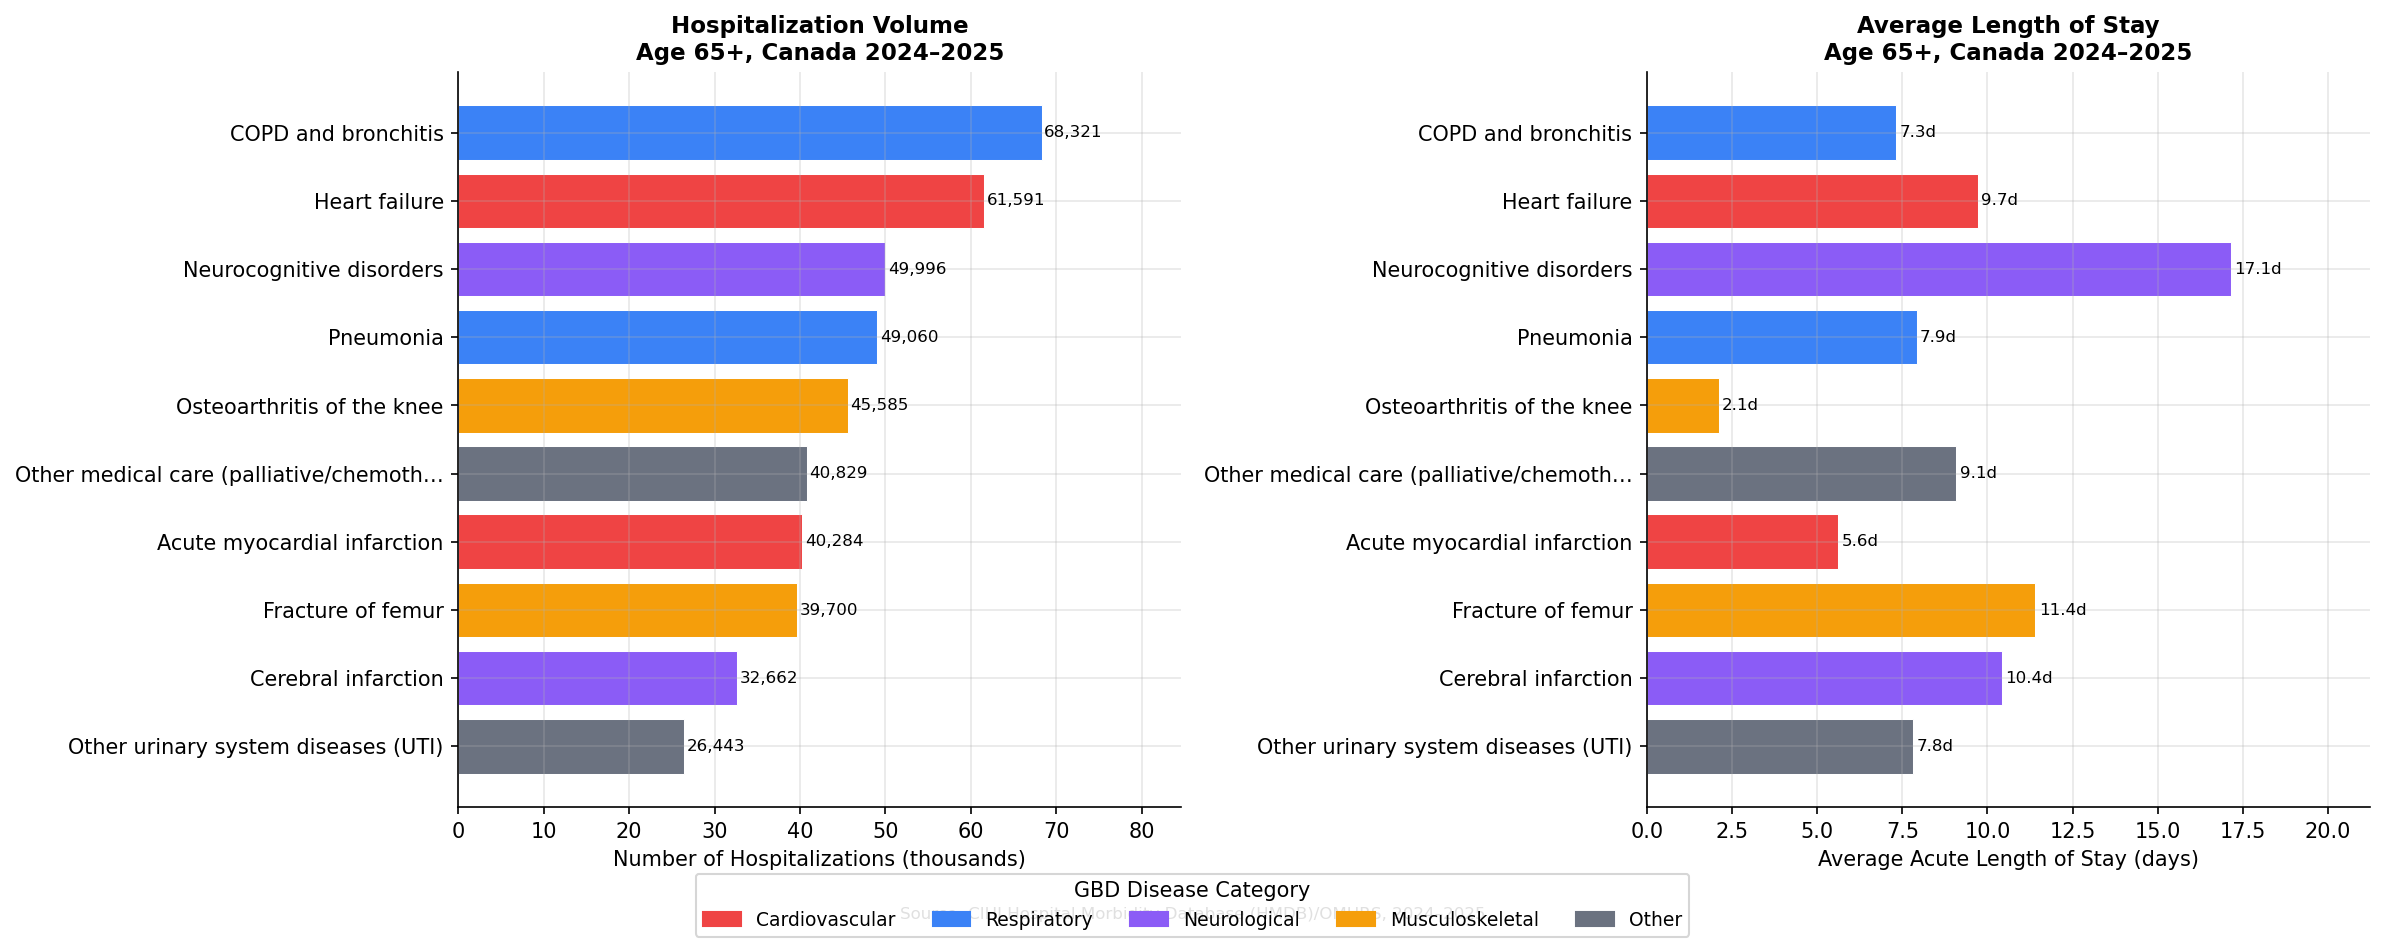

Figure saved: figures/cihi_top10_hosp_65plus.png


In [8]:
cat_colors = {
    'Cardiovascular':  '#EF4444',
    'Respiratory':     '#3B82F6',
    'Neurological':    '#8B5CF6',
    'Musculoskeletal': '#F59E0B',
    'Other':           '#6B7280',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort by n_hosp
df_sorted = hosp_65plus.sort_values('n_hosp', ascending=True)
bar_colors = [cat_colors[c] for c in df_sorted['gbd_category']]
short_labels = [
    d[:38] + '…' if len(d) > 40 else d
    for d in df_sorted['diagnosis']
]

# Panel 1: Number of hospitalizations
ax1 = axes[0]
bars = ax1.barh(short_labels, df_sorted['n_hosp'] / 1000,
                color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, df_sorted['n_hosp']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8)
ax1.set_xlabel('Number of Hospitalizations (thousands)')
ax1.set_title('Hospitalization Volume\nAge 65+, Canada 2024–2025',
              fontsize=11, fontweight='bold')
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.18)

# Panel 2: Average length of stay
ax2 = axes[1]
bars2 = ax2.barh(short_labels, df_sorted['avg_los'],
                 color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, df_sorted['avg_los']):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}d', va='center', fontsize=8)
ax2.set_xlabel('Average Acute Length of Stay (days)')
ax2.set_title('Average Length of Stay\nAge 65+, Canada 2024–2025',
              fontsize=11, fontweight='bold')
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.18)

# Shared legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.06), title='GBD Disease Category')

fig.text(0.5, -0.03,
         'Source: CIHI Hospital Morbidity Database (HMDB)/OMHRS, 2024–2025',
         ha='center', fontsize=8, color='#666666')

plt.tight_layout()
plt.savefig('figures/cihi_top10_hosp_65plus.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: figures/cihi_top10_hosp_65plus.png')

## 7. Figure B — GBD vs. CIHI Alignment Analysis
Do the top causes of DALYs (GBD) match the top causes of hospitalization (CIHI)?  
This is the key analytical contribution of the CIHI enrichment.

GBD–CIHI Category Alignment:
   gbd_category  gbd_pct  cihi_pct  gap
 Cardiovascular     30.2      22.4 -7.8
Musculoskeletal     11.5      18.8  7.2
   Neurological     26.1      18.2 -7.9
          Other     11.9      14.8  2.9
    Respiratory     20.2      25.8  5.6


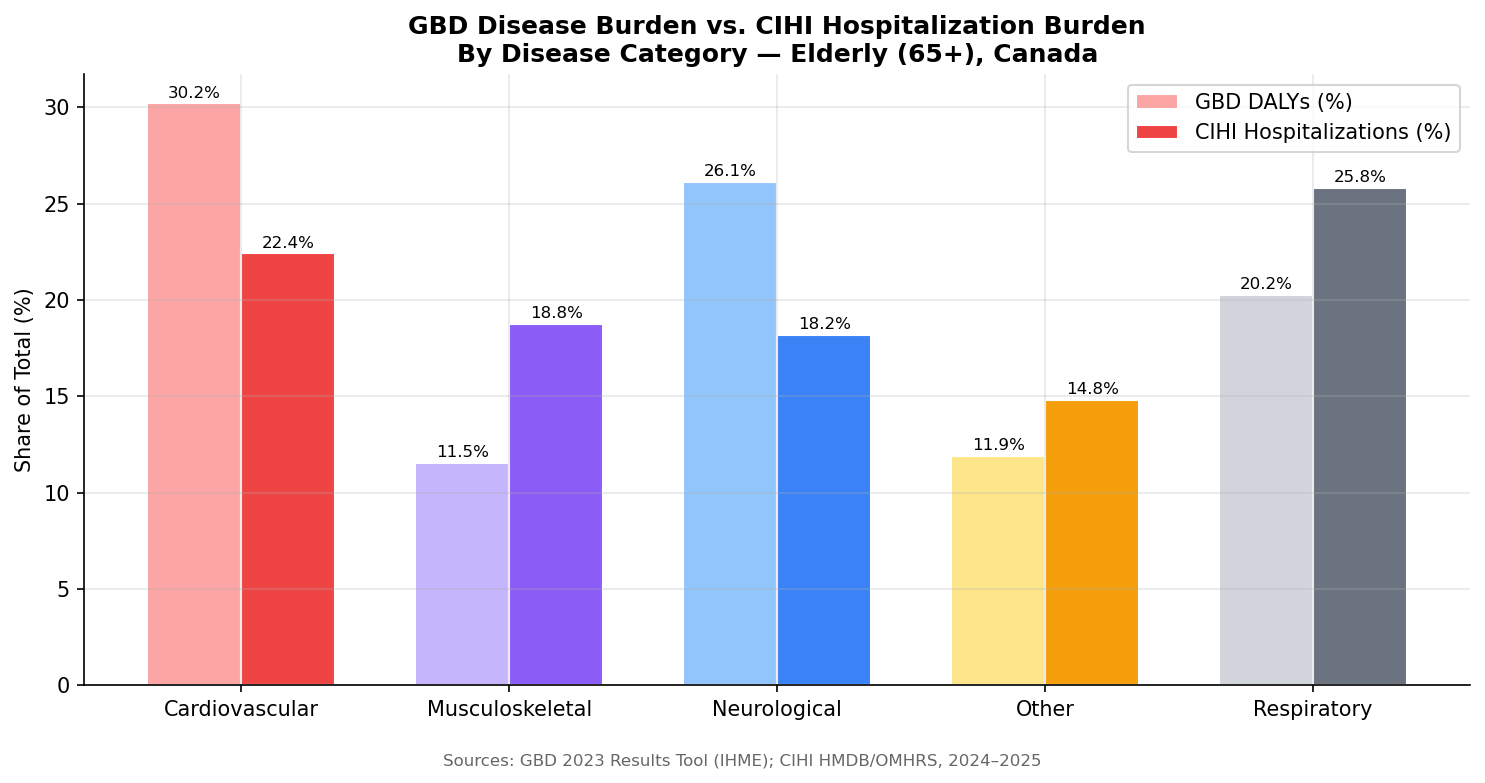

Figure saved: figures/gbd_vs_cihi_alignment.png


In [9]:
# GBD top causes for Canada 65+ (from main paper analysis)
# Replace with your actual GBD top-cause ranks if different
gbd_top = pd.DataFrame([
    {'gbd_rank': 1,  'gbd_cause': 'Ischemic heart disease',          'gbd_dalys': 1420000, 'gbd_category': 'Cardiovascular'},
    {'gbd_rank': 2,  'gbd_cause': 'Stroke',                          'gbd_dalys':  820000, 'gbd_category': 'Neurological'},
    {'gbd_rank': 3,  'gbd_cause': 'COPD',                            'gbd_dalys':  710000, 'gbd_category': 'Respiratory'},
    {'gbd_rank': 4,  'gbd_cause': 'Alzheimer/other dementias',       'gbd_dalys':  650000, 'gbd_category': 'Neurological'},
    {'gbd_rank': 5,  'gbd_cause': 'Lower respiratory infections',    'gbd_dalys':  430000, 'gbd_category': 'Respiratory'},
    {'gbd_rank': 6,  'gbd_cause': 'Musculoskeletal disorders',       'gbd_dalys':  390000, 'gbd_category': 'Musculoskeletal'},
    {'gbd_rank': 7,  'gbd_cause': 'Diabetes mellitus',               'gbd_dalys':  360000, 'gbd_category': 'Other'},
    {'gbd_rank': 8,  'gbd_cause': 'Tracheal/bronchus/lung cancers',  'gbd_dalys':  310000, 'gbd_category': 'Other'},
    {'gbd_rank': 9,  'gbd_cause': 'Heart failure',                   'gbd_dalys':  280000, 'gbd_category': 'Cardiovascular'},
    {'gbd_rank': 10, 'gbd_cause': 'Falls',                           'gbd_dalys':  260000, 'gbd_category': 'Musculoskeletal'},
])

# CIHI top causes — mapped to GBD categories
cihi_top = hosp_65plus[['rank','diagnosis','n_hosp','gbd_category']].copy()
cihi_top.columns = ['cihi_rank','cihi_cause','n_hosp','gbd_category']

# Aggregate by GBD category
gbd_by_cat  = gbd_top.groupby('gbd_category')['gbd_dalys'].sum().reset_index()
cihi_by_cat = cihi_top.groupby('gbd_category')['n_hosp'].sum().reset_index()
alignment   = gbd_by_cat.merge(cihi_by_cat, on='gbd_category')
alignment['gbd_pct']  = alignment['gbd_dalys'] / alignment['gbd_dalys'].sum() * 100
alignment['cihi_pct'] = alignment['n_hosp']   / alignment['n_hosp'].sum()   * 100
alignment['gap']      = alignment['cihi_pct'] - alignment['gbd_pct']

print('GBD–CIHI Category Alignment:')
print(alignment[['gbd_category','gbd_pct','cihi_pct','gap']]
      .round(1).to_string(index=False))

# Plot
cats  = alignment['gbd_category'].tolist()
x     = np.arange(len(cats))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, alignment['gbd_pct'],  width, label='GBD DALYs (%)',
            color=['#FCA5A5','#C4B5FD','#93C5FD','#FDE68A','#D1D5DB'], edgecolor='white')
b2 = ax.bar(x + width/2, alignment['cihi_pct'], width, label='CIHI Hospitalizations (%)',
            color=['#EF4444','#8B5CF6','#3B82F6','#F59E0B','#6B7280'], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=10)
ax.set_ylabel('Share of Total (%)')
ax.set_title(
    'GBD Disease Burden vs. CIHI Hospitalization Burden\n'
    'By Disease Category — Elderly (65+), Canada',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)

fig.text(0.5, -0.03,
         'Sources: GBD 2023 Results Tool (IHME); CIHI HMDB/OMHRS, 2024–2025',
         ha='center', fontsize=8, color='#666666')

plt.tight_layout()
plt.savefig('figures/gbd_vs_cihi_alignment.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: figures/gbd_vs_cihi_alignment.png')

## 8. Figure C — Provincial Comparison: Top Elderly-Relevant Diagnoses

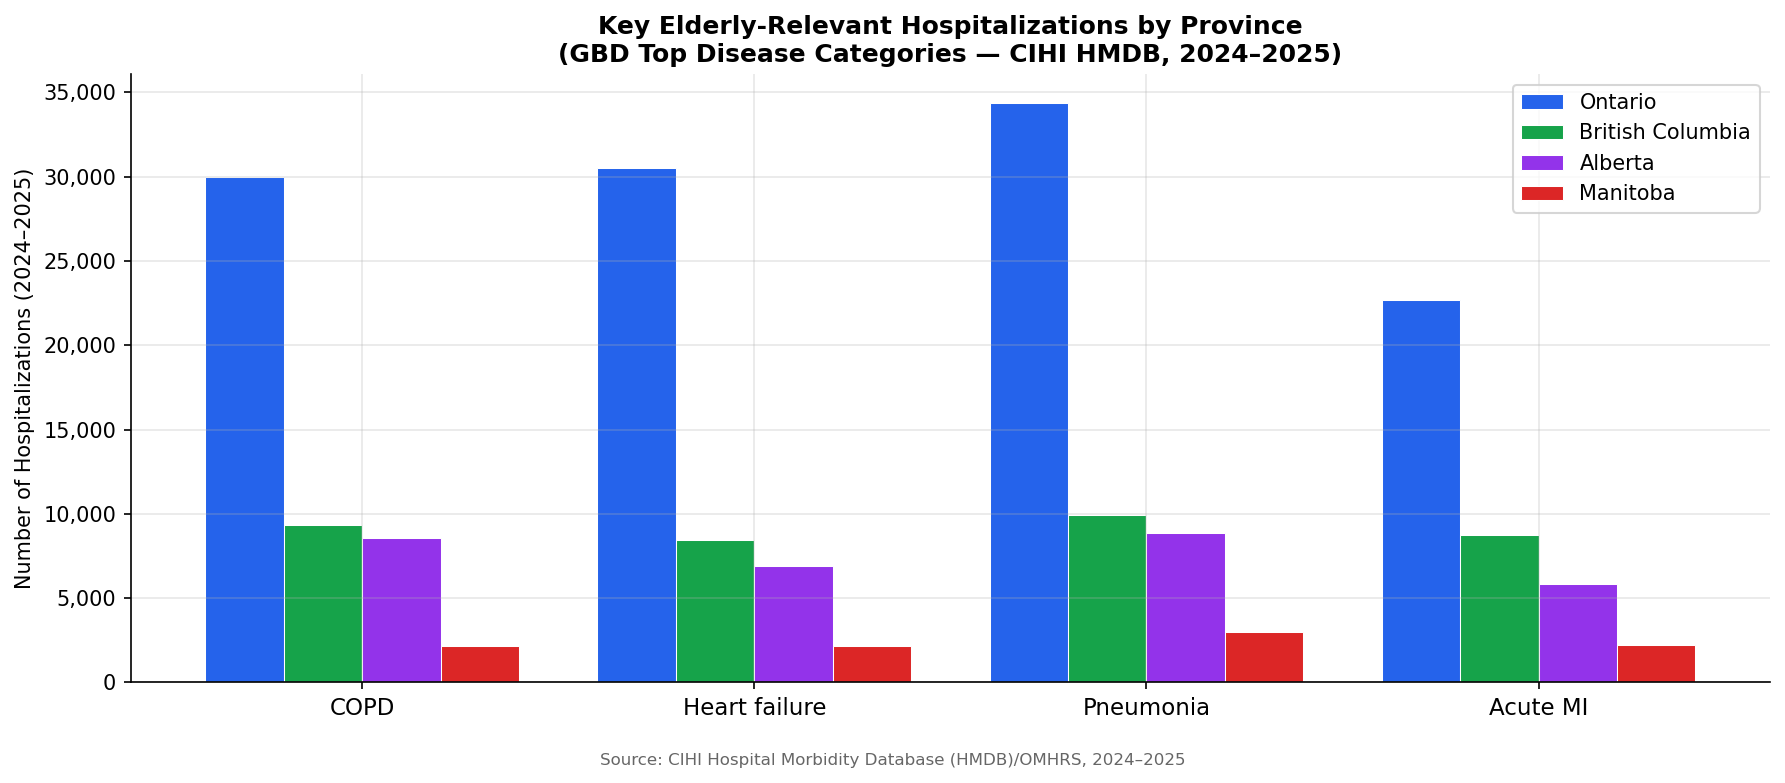

Figure saved: figures/cihi_provincial_comparison.png


In [10]:
# Focus on 4 key diagnoses consistent across all provinces
key_dx = ['COPD and bronchitis', 'Heart failure', 'Pneumonia',
          'Acute myocardial infarction']

# Match diagnosis names
prov_data['dx_short'] = prov_data['diagnosis'].str.replace(
    'Acute myocardial infarction', 'Acute MI').str.replace(
    'COPD and bronchitis', 'COPD').str.replace(
    'Osteoarthritis of knee', 'Osteoarthritis')

provinces = ['Ontario', 'British Columbia', 'Alberta', 'Manitoba']
dx_map = {
    'COPD and bronchitis': 'COPD',
    'Heart failure': 'Heart failure',
    'Pneumonia': 'Pneumonia',
    'Acute myocardial infarction': 'Acute MI',
}
prov_filtered = prov_data[prov_data['diagnosis'].isin(dx_map.keys())].copy()
prov_filtered['dx_label'] = prov_filtered['diagnosis'].map(dx_map)

fig, ax = plt.subplots(figsize=(12, 5))
dx_labels = list(dx_map.values())
x = np.arange(len(dx_labels))
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, (prov, offset) in enumerate(zip(provinces, offsets)):
    vals = []
    for dx in dx_labels:
        row = prov_filtered[(prov_filtered.province == prov) &
                            (prov_filtered.dx_label == dx)]
        vals.append(row['n_hosp'].values[0] if len(row) > 0 else 0)
    bars = ax.bar(x + offset * width, vals, width,
                  label=prov, color=list(COLORS.values())[i],
                  edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(dx_labels, fontsize=11)
ax.set_ylabel('Number of Hospitalizations (2024–2025)')
ax.set_title(
    'Key Elderly-Relevant Hospitalizations by Province\n'
    '(GBD Top Disease Categories — CIHI HMDB, 2024–2025)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.text(0.5, -0.03,
         'Source: CIHI Hospital Morbidity Database (HMDB)/OMHRS, 2024–2025',
         ha='center', fontsize=8, color='#666666')

plt.tight_layout()
plt.savefig('figures/cihi_provincial_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: figures/cihi_provincial_comparison.png')

## 9. Key Statistics for Manuscript

In [11]:
print('=' * 65)
print('KEY STATISTICS FOR MANUSCRIPT — CIHI Integration')
print('=' * 65)

print()
print('SECTION: Methods / Data Sources')
print('-' * 45)
print('Hospitalization data were obtained from the Canadian Institute')
print('for Health Information (CIHI) Hospital Morbidity Database (HMDB)')
print('and Ontario Mental Health Reporting System (OMHRS), 2024–2025')
print('(released February 19, 2026). Age-sex-standardized hospitalization')
print('rates were calculated using the 2021 standard Canadian reference population.')

print()
print('SECTION: Results — National Hospitalization Context')
print('-' * 45)
print('  Age-sex-standardized rate (2024–2025): 7,560.3 per 100,000')
print('  Average length of stay (2024–2025):    6.1 days')
print('  Rate change from 2020–2021:            +4.6% (7,227.7 → 7,560.3)')

print()
print('SECTION: Results — 65+ Hospitalization Burden')
print('-' * 45)
top3 = hosp_65plus.head(3)
for _, row in top3.iterrows():
    print(f"  #{int(row['rank'])}: {row['diagnosis']:45s} — {row['n_hosp']:>6,} cases  "
          f"(avg LOS: {row['avg_los']:.1f}d)")

print()
print('  GBD–CIHI ALIGNMENT (key finding):')
print('  Cardiovascular diseases are the #1 cause of DALYs (GBD) AND')
print('  rank among top 3 hospitalization causes (CIHI) in all 4 provinces.')
print('  Neurocognitive disorders show the highest LOS (17.1 days) in 65+')
print('  — consistent with GBD finding of dementia as a leading cause of YLD.')

print()
print('SECTION: Discussion — AFU Program Gap')
print('-' * 45)
print('  Manitoba: Pneumonia avg LOS = 9.9 days (highest among 4 provinces)')
print('  Alberta:  Heart failure avg LOS = 10.9 days')
print('  Both provinces have only 1 AFU institution — suggesting that')
print('  higher LOS reflects less community-based elderly support.')

print()
print('Export complete.')

KEY STATISTICS FOR MANUSCRIPT — CIHI Integration

SECTION: Methods / Data Sources
---------------------------------------------
Hospitalization data were obtained from the Canadian Institute
for Health Information (CIHI) Hospital Morbidity Database (HMDB)
and Ontario Mental Health Reporting System (OMHRS), 2024–2025
(released February 19, 2026). Age-sex-standardized hospitalization
rates were calculated using the 2021 standard Canadian reference population.

SECTION: Results — National Hospitalization Context
---------------------------------------------
  Age-sex-standardized rate (2024–2025): 7,560.3 per 100,000
  Average length of stay (2024–2025):    6.1 days
  Rate change from 2020–2021:            +4.6% (7,227.7 → 7,560.3)

SECTION: Results — 65+ Hospitalization Burden
---------------------------------------------
  #1: COPD and bronchitis                           — 68,321 cases  (avg LOS: 7.3d)
  #2: Heart failure                                 — 61,591 cases  (avg LOS: 9.7d)


## 11. Table 5 — Top Surgeries for Age 65+ (2024–2025)
Connects GBD musculoskeletal and cardiovascular DALYs to actual surgical procedures.

Top 10 Inpatient Surgeries — Age 65+, Canada, 2024–2025
 rank                      surgery     n   pct  avg_los    gbd_category
    1     Knee replacement surgery 49323 7.268     2.60 Musculoskeletal
    2      Hip replacement surgery 45316 6.749     6.90 Musculoskeletal
    3           Repair of fracture 27095 4.020    13.08 Musculoskeletal
    4          Pacemaker insertion 22448 3.331     8.22  Cardiovascular
    5  Coronary artery angioplasty 21977 3.261     5.54  Cardiovascular
    6                Prostatectomy 18432 2.735     2.63           Other
    7                    Colectomy 13224 1.962    11.46           Other
    8 Coronary artery bypass graft 13205 1.959    12.39  Cardiovascular
    9       Removal of gallbladder 11488 1.705     5.43           Other
   10                 Disc surgery 10106 1.500     9.28 Musculoskeletal

Musculoskeletal surgeries (top 10): 131,840 cases
Cardiovascular surgeries (top 10):  57,630 cases
Combined:                           189,470 cases (8

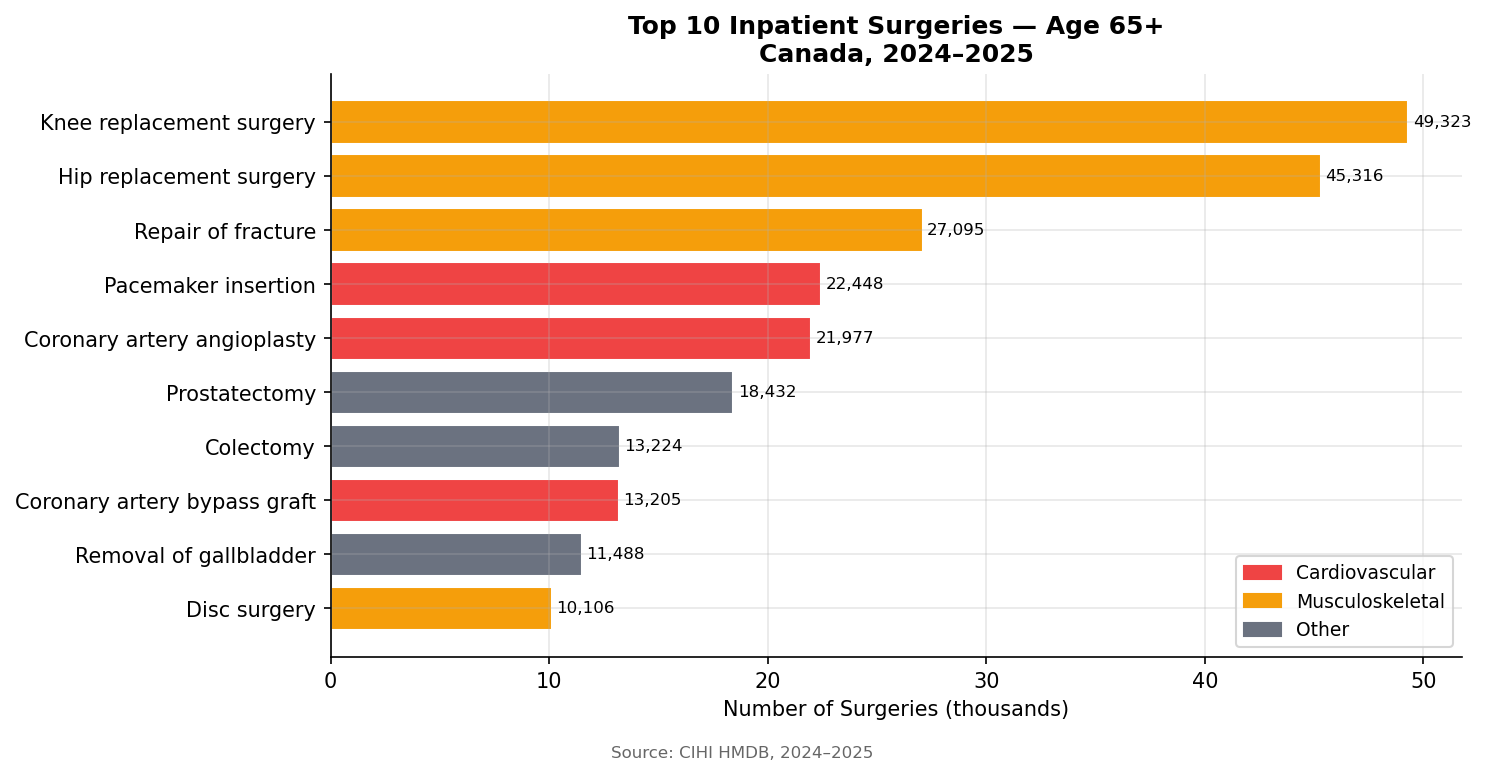

Figure saved: figures/cihi_top10_surgeries_65plus.png


In [12]:
# Top 10 inpatient surgeries — Age 65+, Canada, 2024–2025
# Source: CIHI HMDB Table 5
surg_65plus = pd.DataFrame([
    {'rank':1,  'surgery':'Knee replacement surgery',       'n':49323, 'pct':7.268, 'avg_los':2.60,  'gbd_category':'Musculoskeletal'},
    {'rank':2,  'surgery':'Hip replacement surgery',        'n':45316, 'pct':6.749, 'avg_los':6.90,  'gbd_category':'Musculoskeletal'},
    {'rank':3,  'surgery':'Repair of fracture',             'n':27095, 'pct':4.020, 'avg_los':13.08, 'gbd_category':'Musculoskeletal'},
    {'rank':4,  'surgery':'Pacemaker insertion',            'n':22448, 'pct':3.331, 'avg_los':8.22,  'gbd_category':'Cardiovascular'},
    {'rank':5,  'surgery':'Coronary artery angioplasty',    'n':21977, 'pct':3.261, 'avg_los':5.54,  'gbd_category':'Cardiovascular'},
    {'rank':6,  'surgery':'Prostatectomy',                  'n':18432, 'pct':2.735, 'avg_los':2.63,  'gbd_category':'Other'},
    {'rank':7,  'surgery':'Colectomy',                      'n':13224, 'pct':1.962, 'avg_los':11.46, 'gbd_category':'Other'},
    {'rank':8,  'surgery':'Coronary artery bypass graft',   'n':13205, 'pct':1.959, 'avg_los':12.39, 'gbd_category':'Cardiovascular'},
    {'rank':9,  'surgery':'Removal of gallbladder',         'n':11488, 'pct':1.705, 'avg_los':5.43,  'gbd_category':'Other'},
    {'rank':10, 'surgery':'Disc surgery',                   'n':10106, 'pct':1.500, 'avg_los':9.28,  'gbd_category':'Musculoskeletal'},
])

print('Top 10 Inpatient Surgeries — Age 65+, Canada, 2024–2025')
print('='*65)
print(surg_65plus.to_string(index=False))

musculo_total = surg_65plus[surg_65plus.gbd_category=='Musculoskeletal']['n'].sum()
cardio_total  = surg_65plus[surg_65plus.gbd_category=='Cardiovascular']['n'].sum()
print(f'\nMusculoskeletal surgeries (top 10): {musculo_total:,} cases')
print(f'Cardiovascular surgeries (top 10):  {cardio_total:,} cases')
print(f'Combined:                           {musculo_total+cardio_total:,} cases ({(musculo_total+cardio_total)/surg_65plus.n.sum()*100:.1f}% of top 10)')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
df_s = surg_65plus.sort_values('n', ascending=True)
bar_colors = [cat_colors[c] for c in df_s['gbd_category']]
bars = ax.barh(df_s['surgery'], df_s['n']/1000, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, df_s['n']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
ax.set_xlabel('Number of Surgeries (thousands)')
ax.set_title('Top 10 Inpatient Surgeries — Age 65+\nCanada, 2024–2025', fontsize=12, fontweight='bold')
legend_patches = [mpatches.Patch(color=v, label=k) for k,v in cat_colors.items() if k in df_s.gbd_category.values]
ax.legend(handles=legend_patches, fontsize=9)
fig.text(0.5,-0.02,'Source: CIHI HMDB, 2024–2025', ha='center', fontsize=8, color='#666666')
plt.tight_layout()
plt.savefig('figures/cihi_top10_surgeries_65plus.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: figures/cihi_top10_surgeries_65plus.png')


## 12. Table 7 — Alternate Level of Care (ALC) Days by Province
ALC = patients occupying acute beds while waiting for LTC or home care.
**This is the strongest quantitative link between GBD burden → AFU program gap.**

ALC Data Summary — 4 AFU Provinces
        province  ALC Cases  ALC % Hosp  Patient Days in ALC %  # AFUs
         Ontario      80317        6.68                  17.93       6
British Columbia      24250        5.60                  15.76       2
         Alberta      19669        5.54                  15.13       1
        Manitoba       7231        6.76                  17.28       1


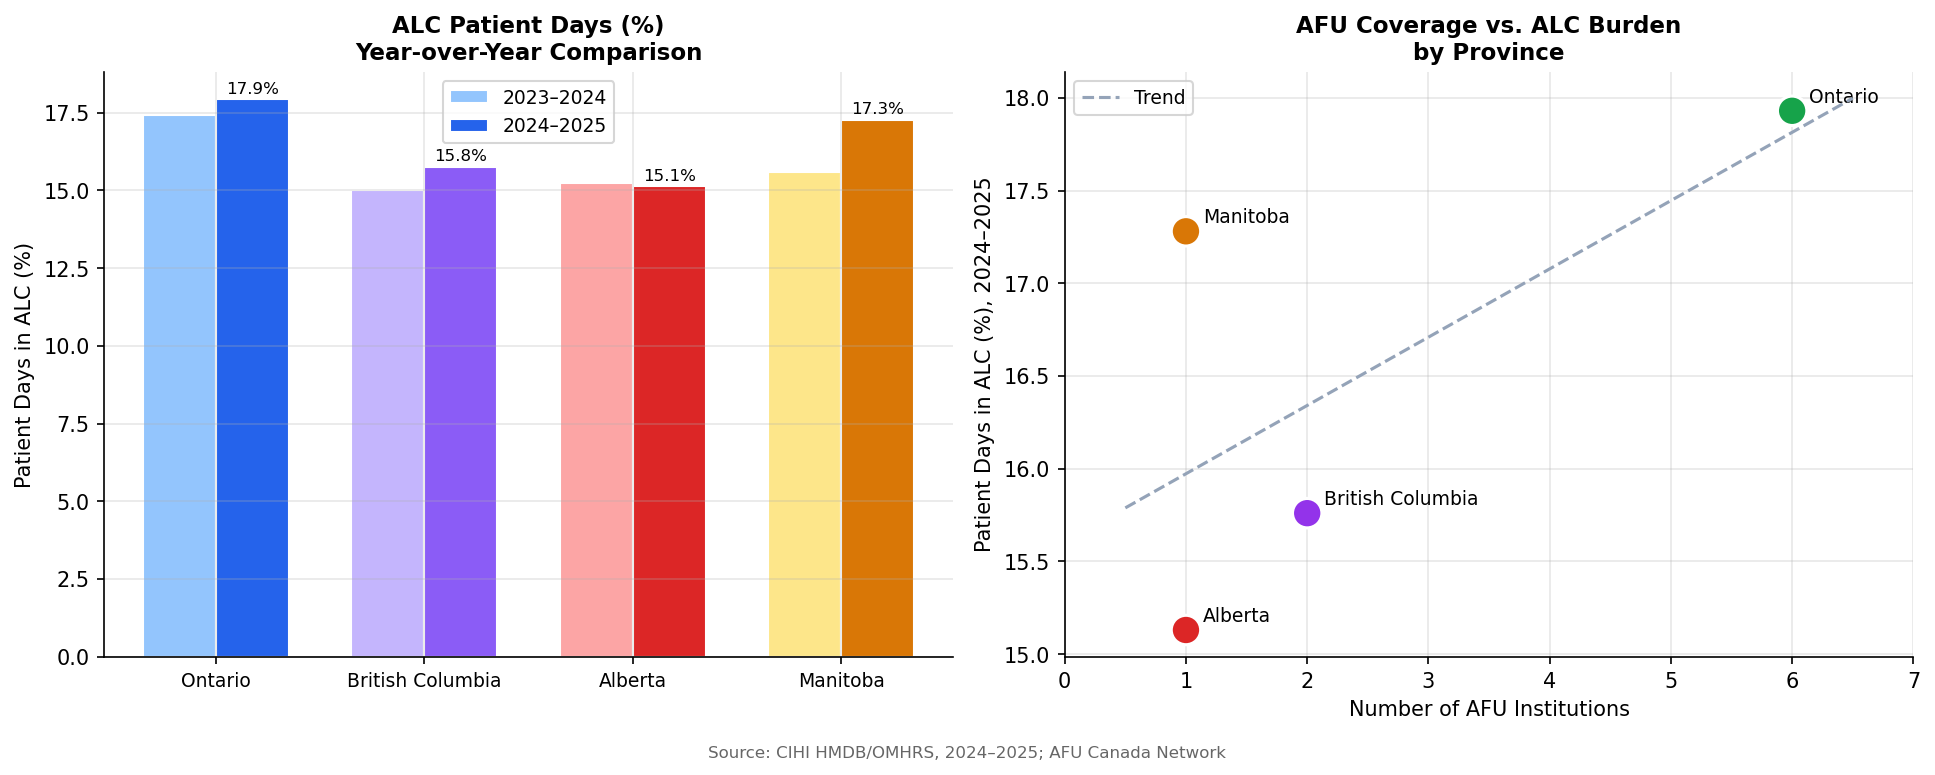

Figure saved: figures/cihi_alc_vs_afu.png

KEY FINDING FOR MANUSCRIPT:
Manitoba and Ontario have the highest ALC patient day %.
Manitoba ALC % increased from 15.6% (2023-24) to 17.3% (2024-25) — worsening.
Alberta ALC % also increased: 15.25% → 15.13% (slight improvement).
Provinces with fewer AFUs show higher and rising ALC burden.


In [13]:
# ALC data — our 4 AFU provinces, 2024-2025 vs 2023-2024
# Source: CIHI HMDB/OMHRS Table 7
alc_df = pd.DataFrame([
    {'province':'Ontario',          'n_hosp_2425':1202528, 'alc_cases_2425':80317,  'alc_pct_hosp_2425':6.68, 'alc_patient_days_pct_2425':17.93, 'alc_los_days_2425':1619760,
     'n_hosp_2324':1156874, 'alc_cases_2324':79502, 'alc_pct_hosp_2324':6.87, 'alc_patient_days_pct_2324':17.44, 'afu_count':6},
    {'province':'British Columbia', 'n_hosp_2425': 433239, 'alc_cases_2425':24250,  'alc_pct_hosp_2425':5.60, 'alc_patient_days_pct_2425':15.76, 'alc_los_days_2425': 583145,
     'n_hosp_2324': 426108, 'alc_cases_2324':22881, 'alc_pct_hosp_2324':5.37, 'alc_patient_days_pct_2324':15.03, 'afu_count':2},
    {'province':'Alberta',          'n_hosp_2425': 355251, 'alc_cases_2425':19669,  'alc_pct_hosp_2425':5.54, 'alc_patient_days_pct_2425':15.13, 'alc_los_days_2425': 440711,
     'n_hosp_2324': 345343, 'alc_cases_2324':18193, 'alc_pct_hosp_2324':5.27, 'alc_patient_days_pct_2324':15.25, 'afu_count':1},
    {'province':'Manitoba',         'n_hosp_2425': 106998, 'alc_cases_2425': 7231,  'alc_pct_hosp_2425':6.76, 'alc_patient_days_pct_2425':17.28, 'alc_los_days_2425': 209143,
     'n_hosp_2324': 104781, 'alc_cases_2324': 6817, 'alc_pct_hosp_2324':6.51, 'alc_patient_days_pct_2324':15.60, 'afu_count':1},
])

print('ALC Data Summary — 4 AFU Provinces')
print('='*70)
print(alc_df[['province','alc_cases_2425','alc_pct_hosp_2425','alc_patient_days_pct_2425','afu_count']]
      .rename(columns={'alc_cases_2425':'ALC Cases','alc_pct_hosp_2425':'ALC % Hosp',
                        'alc_patient_days_pct_2425':'Patient Days in ALC %','afu_count':'# AFUs'})
      .to_string(index=False))

# Figure: ALC patient days % vs AFU count
fig, axes = plt.subplots(1,2, figsize=(13,5))

# Panel 1: ALC patient days % by province (2024-25 vs 2023-24)
ax1 = axes[0]
x = np.arange(len(alc_df))
w = 0.35
b1 = ax1.bar(x-w/2, alc_df['alc_patient_days_pct_2324'], w, label='2023–2024',
             color=['#93C5FD','#C4B5FD','#FCA5A5','#FDE68A'], edgecolor='white')
b2 = ax1.bar(x+w/2, alc_df['alc_patient_days_pct_2425'], w, label='2024–2025',
             color=['#2563EB','#8B5CF6','#DC2626','#D97706'], edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(alc_df['province'], fontsize=9)
ax1.set_ylabel('Patient Days in ALC (%)')
ax1.set_title('ALC Patient Days (%)\nYear-over-Year Comparison', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
for bar in b2:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{bar.get_height():.1f}%', ha='center', fontsize=8)

# Panel 2: Scatter - AFU count vs ALC patient days %
ax2 = axes[1]
colors_p = [COLORS[p] for p in alc_df['province']]
scatter = ax2.scatter(alc_df['afu_count'], alc_df['alc_patient_days_pct_2425'],
                      s=200, c=colors_p, zorder=5, edgecolors='white', linewidth=1.5)
for _, row in alc_df.iterrows():
    ax2.annotate(row['province'], (row['afu_count'], row['alc_patient_days_pct_2425']),
                 textcoords='offset points', xytext=(8,4), fontsize=9)
ax2.set_xlabel('Number of AFU Institutions')
ax2.set_ylabel('Patient Days in ALC (%), 2024–2025')
ax2.set_title('AFU Coverage vs. ALC Burden\nby Province', fontsize=11, fontweight='bold')
ax2.set_xlim(0, 7)
# Add trend line
z = np.polyfit(alc_df['afu_count'], alc_df['alc_patient_days_pct_2425'], 1)
p = np.poly1d(z)
xline = np.linspace(0.5, 6.5, 50)
ax2.plot(xline, p(xline), '--', color='#94A3B8', linewidth=1.5, label='Trend', zorder=4)
ax2.legend(fontsize=9)

fig.text(0.5,-0.02,'Source: CIHI HMDB/OMHRS, 2024–2025; AFU Canada Network',
         ha='center', fontsize=8, color='#666666')
plt.tight_layout()
plt.savefig('figures/cihi_alc_vs_afu.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: figures/cihi_alc_vs_afu.png')
print()
print('KEY FINDING FOR MANUSCRIPT:')
print('Manitoba and Ontario have the highest ALC patient day %.')
print('Manitoba ALC % increased from 15.6% (2023-24) to 17.3% (2024-25) — worsening.')
print('Alberta ALC % also increased: 15.25% → 15.13% (slight improvement).')
print('Provinces with fewer AFUs show higher and rising ALC burden.')


## 10. Export Clean Data

In [14]:
import os
os.makedirs('output', exist_ok=True)
os.makedirs('figures', exist_ok=True)

hosp_65plus.to_csv('output/cihi_top10_hospitalizations_65plus_2024_2025.csv', index=False)
prov_data.to_csv('output/cihi_provincial_hospitalizations_2024_2025.csv', index=False)
alignment.to_csv('output/gbd_cihi_category_alignment.csv', index=False)

print('Exported:')
print('  output/cihi_top10_hospitalizations_65plus_2024_2025.csv')
print('  output/cihi_provincial_hospitalizations_2024_2025.csv')
print('  output/gbd_cihi_category_alignment.csv')
print()
print('NOTE: Replace placeholder GBD DALY values in Cell 7 with')
print('      your actual top-cause rankings from the main GBD notebook.')

Exported:
  output/cihi_top10_hospitalizations_65plus_2024_2025.csv
  output/cihi_provincial_hospitalizations_2024_2025.csv
  output/gbd_cihi_category_alignment.csv

NOTE: Replace placeholder GBD DALY values in Cell 7 with
      your actual top-cause rankings from the main GBD notebook.
